In [1]:
#! Package required to read the PINNED PACS metadata only at final evaluation
%pip -q install datasets huggingface_hub

In [2]:
#! Fixed paths, experiment completion, checkpoint provenance, immutable evaluation plan
import hashlib
import json
import os
import random
import shutil
import sys
import tempfile

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset
from torchvision import models

drive.mount('/content/drive')

SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH = 32 if DEVICE.type == 'cuda' else 8

SOURCE_DOMAINS = ('photo', 'art_painting', 'cartoon')
MAIN_NAMES = ('erm', 'dan_dg', 'sam')
CONTROL_NAMES = ('dan_dg_0p1', 'dan_dg', 'dan_dg_10')
ALL_NAMES = ('erm', 'dan_dg', 'sam', 'dan_dg_0p1', 'dan_dg_10')
ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')
PACS_DIR, SHARED = ROOT / 'data/pacs', ROOT / 'shared'
TASK2, TASK3 = ROOT / 'task2', ROOT / 'task3'
BASE_PATH = TASK2 / 'configs/base.json'
SPLIT_PATH = SHARED / 'splits/pacs_sketch_seed6304.json'
INITIAL_PATH = TASK2 / 'models/resnet18_initial_seed6304.pt'
PROVENANCE_PATH = PACS_DIR / 'provenance.json'
SOURCE_VAL_PATH = PACS_DIR / 'source_val.csv'
TARGET_PATH = PACS_DIR / 'target_unlabeled.csv'
STUDY_CONFIG = TASK3 / 'configs/dan_dg_controlled.json'
STUDY_TABLE = TASK3 / 'results/dan_dg_controlled/controlled_source_table.csv'
STUDY_SAMPLE = TASK3 / 'results/dan_dg_controlled/source_diagnostic_sample.json'
RESULT_DIR = TASK3 / 'results/final_eval'
CACHE_DIR = RESULT_DIR / 'feature_cache'
FIG_DIR = RESULT_DIR / 'figures'
LOCK_PATH = RESULT_DIR / 'frozen_evaluation_plan.json'

MODEL_SPECS = {
    'erm': ('task2/configs/source_only.json', 'task2/models/source_only_best.pt',
            'task2/models/source_only_last.pt', 'source_only_erm'),
    'dan_dg': ('task3/configs/dan_dg.json', 'task3/models/dan_dg_best.pt',
               'task3/models/dan_dg_last.pt', 'dan_dg'),
    'sam': ('task3/configs/sam.json', 'task3/models/sam_best.pt',
            'task3/models/sam_last.pt', 'sam'),
    'dan_dg_0p1': ('task3/configs/dan_dg_lambda_0p1.json',
                   'task3/models/dan_dg_lambda_0p1_best.pt',
                   'task3/models/dan_dg_lambda_0p1_last.pt', 'dan_dg_controlled'),
    'dan_dg_10': ('task3/configs/dan_dg_lambda_10.json',
                  'task3/models/dan_dg_lambda_10_best.pt',
                  'task3/models/dan_dg_lambda_10_last.pt', 'dan_dg_controlled'),
}

def sha256(path):
    digest = hashlib.sha256()

    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(4 * 1024 * 1024), b''):
            digest.update(block)

    return digest.hexdigest()

def write_json_once(path, data):
    #! A prior final-evaluation decision cannot silently be revised.
    if path.is_file():
        if json.loads(path.read_text()) != data:
            raise RuntimeError('Existing frozen record differs; inspect instead of overwriting: ' + str(path))
    else:
        path.parent.mkdir(parents=True, exist_ok=True)
        partial = path.with_suffix(path.suffix + '.partial')
        partial.write_text(json.dumps(data, indent=2))
        os.replace(partial, path)

required = [BASE_PATH, SPLIT_PATH, INITIAL_PATH, PROVENANCE_PATH,
            SOURCE_VAL_PATH, STUDY_CONFIG, STUDY_TABLE, STUDY_SAMPLE,
            SHARED / 'pacs.py', SHARED / 'pacs_training.py',
            TASK3 / 'methods/dan_dg.py', TASK3 / 'methods/sam_task3.py',
            TASK3 / 'results/dan_dg/source_validation.csv',
            TASK3 / 'results/sam/source_validation.csv',
            TASK3 / 'results/erm_baseline_source.csv',
            PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'pacs_target_unlabeled.tar',
            TARGET_PATH]

for config, best, last, _ in MODEL_SPECS.values():
    required += [ROOT / config, ROOT / best, ROOT / last]

missing = [str(p) for p in required if not p.is_file() or p.stat().st_size == 0]

if missing:
    raise FileNotFoundError('Finish Task 2B and Tasks 3A–3C first. Missing:\n' + '\n'.join(missing))

base = json.loads(BASE_PATH.read_text())
split = json.loads(SPLIT_PATH.read_text())
provenance = json.loads(PROVENANCE_PATH.read_text())
study = json.loads(STUDY_CONFIG.read_text())

LABEL_NAMES = list(base['class_names'])
INITIAL_SHA, BASE_SHA, SPLIT_SHA = sha256(INITIAL_PATH), sha256(BASE_PATH), sha256(SPLIT_PATH)

if (base['seed'] != SEED or split['seed'] != SEED
        or list(base['source_domains']) != list(SOURCE_DOMAINS)
        or base['target_domain'] != 'sketch' or len(LABEL_NAMES) != 7
        or provenance['dataset_revision'] != base['dataset_revision']
        or study['lambda_values'] != [0.1, 1.0, 10.0]
        or study['main_lambda'] != 1.0
        or study['source_split_sha256'] != SPLIT_SHA
        or study['initial_checkpoint_sha256'] != INITIAL_SHA):
    raise RuntimeError('Shared protocol, PACS revision or predeclared controlled study changed')

FROZEN = {}

for name, (config_rel, best_rel, last_rel, method) in MODEL_SPECS.items():
    config_path, best_path, last_path = ROOT / config_rel, ROOT / best_rel, ROOT / last_rel
    cfg = json.loads(config_path.read_text())

    best = torch.load(best_path, map_location='cpu', weights_only=True)
    last = torch.load(last_path, map_location='cpu', weights_only=True)

    config_sha = sha256(config_path)

    if not last.get('finished', False):
        raise RuntimeError(f'{name}: training unfinished; resume that notebook before Task 3D')

    if (cfg['seed'] != SEED or cfg['initial_checkpoint_sha256'] != INITIAL_SHA
            or cfg['source_split_sha256'] != SPLIT_SHA
            or best['method'] != method or best['seed'] != SEED
            or best['class_names'] != LABEL_NAMES
            or best['run_config_sha256'] != config_sha
            or last['run_config_sha256'] != config_sha
            or best['initial_checkpoint_sha256'] != INITIAL_SHA
            or best['epoch'] != last['best_epoch']
            or not np.isclose(best['best_source_val_mean_macro_f1'], last['best_f1'], atol=1e-8)
            or best['model_state_dict']['fc.weight'].shape != (7, 512)
            or not all(torch.isfinite(tensor).all().item()
                       for tensor in best['model_state_dict'].values() if tensor.is_floating_point())):
        raise RuntimeError(f'{name}: checkpoint/config/source selection mismatch')

    if method == 'dan_dg_controlled':
        expected_lambda = 0.1 if name.endswith('0p1') else 10.0

        if (cfg['lambda_dg'] != expected_lambda or best['lambda_dg'] != expected_lambda
                or cfg['parent_study_config_sha256'] != sha256(STUDY_CONFIG)):
            raise RuntimeError(f'{name}: controlled lambda or parent study mismatch')

    if name == 'dan_dg' and cfg['lambda_dg'] != 1.0:
        raise RuntimeError('Main DAN-DG lambda must remain 1')

    if name == 'sam' and cfg['rho'] != 0.05:
        raise RuntimeError('Main SAM rho must remain 0.05')

    FROZEN[name] = {
        'config': config_rel, 'config_sha256': config_sha,
        'best': best_rel, 'best_sha256': sha256(best_path),
        'last': last_rel, 'last_sha256': sha256(last_path),
        'best_epoch': int(best['epoch']),
        'best_source_macro_f1': float(best['best_source_val_mean_macro_f1']),
        'initial_checkpoint_sha256': INITIAL_SHA,
    }
    del best, last

if (study['main_checkpoint_sha256'] != FROZEN['dan_dg']['best_sha256']
        or study['erm_checkpoint_sha256'] != FROZEN['erm']['best_sha256']):
    raise RuntimeError('3C was predeclared against different main DAN-DG / ERM checkpoints')

source_study = pd.read_csv(STUDY_TABLE)

if (source_study.shape[0] != 3
        or sorted(source_study['lambda_dg'].tolist()) != [0.1, 1.0, 10.0]):
    raise RuntimeError('Task 3C source-only results incomplete')

for _, row in source_study.iterrows():
    key = {0.1: 'dan_dg_0p1', 1.0: 'dan_dg', 10.0: 'dan_dg_10'}[float(row['lambda_dg'])]
    if row['checkpoint_sha256'] != FROZEN[key]['best_sha256']:
        raise RuntimeError('3C source table refers to a different selected checkpoint: ' + key)

FROZEN_PLAN = {
    'purpose': 'Task 3 FINAL analysis, no training, source-only selection already finished',
    'seed': SEED, 'main_methods': list(MAIN_NAMES),
    'controlled_lambda': [0.1, 1.0, 10.0], 'main_lambda': 1.0, 'main_rho': 0.05,
    'base_config_sha256': BASE_SHA, 'source_split_sha256': SPLIT_SHA,
    'initial_checkpoint_sha256': INITIAL_SHA,
    'source_validation_manifest_sha256': sha256(SOURCE_VAL_PATH),
    'pacs_module_sha256': sha256(SHARED / 'pacs.py'),
    'training_module_sha256': sha256(SHARED / 'pacs_training.py'),
    'study_config_sha256': sha256(STUDY_CONFIG),
    'study_table_sha256': sha256(STUDY_TABLE),
    'dataset_revision': provenance['dataset_revision'],
    'models': FROZEN,
    'source_probe': {'maximum_per_domain': 256, 'seed': SEED,
                     'train_fraction': 0.7, 'test_fraction': 0.3,
                     'logistic_C': 1.0, 'class_weight': 'balanced',
                     'scaling': 'training split only'},
    'sharpness': {'seed': SEED, 'samples_per_source': 32, 'rho': 0.05,
                  'model_mode': 'eval', 'loss': 'equal-domain mean source CE',
                  'perturbation': 'one global-L2 normalized ascent step'},
    'target_release': 'Only after checkpoint lock and source diagnostics are complete',
}

write_json_once(LOCK_PATH, FROZEN_PLAN)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('FREEZE PASSED: five finished, source-selected checkpoints verified.')
print('Locked method epochs:', {k: v['best_epoch'] for k, v in FROZEN.items()})
print('No Sketch image or class label was opened in this cell.')

Mounted at /content/drive
FREEZE PASSED: five finished, source-selected checkpoints verified.
Locked method epochs: {'erm': 9, 'dan_dg': 3, 'sam': 6, 'dan_dg_0p1': 10, 'dan_dg_10': 2}
No Sketch image or class label was opened in this cell.


In [3]:
#! Source-only validation loader, fixed three-domain probe IDs and sharpness batch
sys.path.insert(0, str(SHARED))

from pacs import PACSDataset, make_transform, prepare_local_data

LOCAL_ROOT = Path('/content/pacs_task3d_final_eval')

if (LOCAL_ROOT / 'images/sketch').exists():
    raise RuntimeError('Fresh Task 3D runtime needed: Sketch images appeared before final-only cell')

prepare_local_data(PACS_DIR, LOCAL_ROOT, include_target=False)
SOURCE_ROWS = pd.read_csv(SOURCE_VAL_PATH).reset_index(drop=True)

if SOURCE_ROWS['hf_index'].duplicated().any():
    raise RuntimeError('Duplicate source-validation image identifiers')

SOURCE_LOADERS, SOURCE_META = {}, {}

for domain in SOURCE_DOMAINS:
    ds = PACSDataset(SOURCE_VAL_PATH, LOCAL_ROOT, make_transform(False), domain=domain)
    rows = SOURCE_ROWS[SOURCE_ROWS.domain == domain].reset_index(drop=True)

    if len(ds) != len(rows) or len(ds) < 32:
        raise RuntimeError('Source validation set missing or too small: ' + domain)

    if set(rows['hf_index']) != set(split['source_splits'][domain]['val_indices']):
        raise RuntimeError('Source validation IDs changed for ' + domain)

    SOURCE_META[domain] = rows
    SOURCE_LOADERS[domain] = DataLoader(ds, batch_size=BATCH, shuffle=False,
                                        num_workers=2, pin_memory=DEVICE.type=='cuda')

SOURCE_IDS = np.concatenate([SOURCE_META[d]['hf_index'].to_numpy(dtype=np.int64) for d in SOURCE_DOMAINS])
SOURCE_TRUE = np.concatenate([SOURCE_META[d]['label'].to_numpy(dtype=np.int64) for d in SOURCE_DOMAINS])

n_probe = min(256, *(len(SOURCE_META[d]) for d in SOURCE_DOMAINS))

probe_indices, sharp_indices = {}, {}
probe_global, probe_domains = [], []

offset = 0

for index, domain in enumerate(SOURCE_DOMAINS):
    rng_probe = np.random.default_rng(SEED + index)
    rng_sharp = np.random.default_rng(SEED + 100 + index)
    probe_indices[domain] = sorted(rng_probe.choice(len(SOURCE_META[domain]), n_probe, replace=False).tolist())
    sharp_indices[domain] = sorted(rng_sharp.choice(len(SOURCE_META[domain]), 32, replace=False).tolist())
    probe_global += [offset + i for i in probe_indices[domain]]
    probe_domains += [index] * n_probe
    offset += len(SOURCE_META[domain])

PROBE_INDICES = np.asarray(probe_global, dtype=np.int64)
PROBE_DOMAINS = np.asarray(probe_domains, dtype=np.int64)
PROBE_TRAIN, PROBE_TEST = train_test_split(
    np.arange(len(PROBE_INDICES)), test_size=0.3,
    random_state=SEED, stratify=PROBE_DOMAINS
)

SAMPLE_RECORD = {
    'seed': SEED, 'probe_n_per_source': n_probe,
    'probe_source_indices': probe_indices,
    'probe_original_hf_indices': SOURCE_IDS[PROBE_INDICES].tolist(),
    'probe_domain_codes': PROBE_DOMAINS.tolist(),
    'probe_train_positions': PROBE_TRAIN.tolist(),
    'probe_test_positions': PROBE_TEST.tolist(),
    'sharpness_n_per_domain': 32,
    'sharpness_source_indices': sharp_indices,
    'sharpness_original_hf_indices': {
        domain: SOURCE_META[domain].iloc[sharp_indices[domain]]['hf_index'].astype(int).tolist()
        for domain in SOURCE_DOMAINS
    },
    'target_access_before_this_sample': False,
}

SAMPLE_PATH = RESULT_DIR / 'frozen_source_diagnostic_samples.json'
write_json_once(SAMPLE_PATH, SAMPLE_RECORD)

print('Source-only loader ready:', len(SOURCE_IDS), 'source validation images.')
print('Source probe:', n_probe, '/domain; train/test:', len(PROBE_TRAIN), len(PROBE_TEST))
print('Sharpness:', 32, 'fixed examples per source; Sketch not loaded.')

Source-only loader ready: 1213 source validation images.
Source probe: 256 /domain; train/test: 537 231
Sharpness: 32 fixed examples per source; Sketch not loaded.


In [4]:
#! Frozen source inference, stable feature cache and checkpoint-selection audit
from sklearn.metrics import accuracy_score, f1_score

def forward_features_logits(model, images):
    #! Exact torchvision ResNet-18 feature path, no external shared modules rewritten.
    x = model.maxpool(model.relu(model.bn1(model.conv1(images))))
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)

    features = torch.flatten(model.avgpool(x), 1)
    return features, model.fc(features)

def load_frozen_model(name):
    checkpoint = torch.load(ROOT / FROZEN[name]['best'], map_location='cpu', weights_only=True)

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 7)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)

    return model.to(DEVICE).eval()

@torch.inference_mode()

def extract_loader(model, loader, labeled):
    vectors, logits, targets = [], [], []

    for batch in loader:
        if labeled:
            images, labels = batch
            targets.append(labels.numpy())
        else:
            images = batch

        feats, scores = forward_features_logits(model, images.to(DEVICE, non_blocking=True))

        vectors.append(feats.detach().float().cpu().numpy())
        logits.append(scores.detach().float().cpu().numpy())

    features = np.concatenate(vectors).astype(np.float32)
    scores = np.concatenate(logits).astype(np.float32)
    labels = np.concatenate(targets) if labeled else None

    if (features.shape[1] != 512 or scores.shape != (len(features), 7)
            or not np.isfinite(features).all() or not np.isfinite(scores).all()):
        raise FloatingPointError('Frozen inference produced invalid features or logits')

    return features, scores, labels

def metrics(y, pred):
    return {'accuracy': float(accuracy_score(y, pred)),
            'macro_f1': float(f1_score(y, pred, labels=np.arange(7),
                                       average='macro', zero_division=0))}

def cache_npz(path, meta_path, expected, builder):
    #! Cache is immutable with respect to checkpoint, input IDs, and transform.
    if path.exists() or meta_path.exists():
        if (not path.is_file() or not meta_path.is_file()
                or json.loads(meta_path.read_text()).get('config') != expected
                or json.loads(meta_path.read_text()).get('sha256') != sha256(path)):
            raise RuntimeError('Existing feature cache incomplete or stale: ' + str(path))
    else:
        arrays = builder()

        with tempfile.TemporaryDirectory(dir='/content') as folder:
            temporary = Path(folder) / 'features.npz'
            np.savez_compressed(temporary, **arrays)
            staged = path.with_suffix(path.suffix + '.partial')
            shutil.copy2(temporary, staged)
            os.replace(staged, path)

        write_json_once(meta_path, {'config': expected, 'sha256': sha256(path)})
    with np.load(path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}

SOURCE_FEATURES, SOURCE_METRIC_ROWS = {}, []

for name in ALL_NAMES:
    model = load_frozen_model(name)

    cache_path = CACHE_DIR / f'{name}_source.npz'
    meta_path = CACHE_DIR / f'{name}_source_meta.json'

    expected = {'checkpoint_sha256': FROZEN[name]['best_sha256'],
                'manifest_sha256': sha256(SOURCE_VAL_PATH),
                'transform': base['eval_transform'], 'seed': SEED, 'precision': 'FP32'}

    def build_source():
        feat_groups, score_groups, target_groups = [], [], []

        for domain in SOURCE_DOMAINS:
            f, z, y = extract_loader(model, SOURCE_LOADERS[domain], labeled=True)

            if not np.array_equal(y, SOURCE_META[domain]['label'].to_numpy(dtype=np.int64)):
                raise RuntimeError('Source order/label mismatch in ' + domain)

            feat_groups.append(f)
            score_groups.append(z)
            target_groups.append(y)

        return {'features': np.concatenate(feat_groups),
                'logits': np.concatenate(score_groups),
                'labels': np.concatenate(target_groups), 'hf_indices': SOURCE_IDS}

    result = cache_npz(cache_path, meta_path, expected, build_source)

    if (not np.array_equal(result['hf_indices'], SOURCE_IDS)
            or not np.array_equal(result['labels'], SOURCE_TRUE)
            or result['features'].shape != (len(SOURCE_IDS), 512)
            or result['logits'].shape != (len(SOURCE_IDS), 7)
            or not np.isfinite(result['features']).all()
            or not np.isfinite(result['logits']).all()):
        raise RuntimeError('Source cache identity, shape or finiteness mismatch: ' + name)

    SOURCE_FEATURES[name] = result

    y_pred = result['logits'].argmax(axis=1)
    offset, scores_a, scores_f = 0, [], []

    for domain in SOURCE_DOMAINS:
        n = len(SOURCE_META[domain])
        measured = metrics(SOURCE_TRUE[offset:offset+n], y_pred[offset:offset+n])

        SOURCE_METRIC_ROWS.append({'method': name, 'domain': domain, 'n': n, **measured})
        scores_a.append(measured['accuracy'])
        scores_f.append(measured['macro_f1'])
        offset += n

    if not np.isclose(np.mean(scores_f), FROZEN[name]['best_source_macro_f1'], atol=2e-5, rtol=0):
        raise RuntimeError(name + ': source validation does not reproduce source-selected F1; stop before Sketch')

    SOURCE_METRIC_ROWS.extend([
        {'method': name, 'domain': 'mean', 'n': len(SOURCE_IDS),
         'accuracy': float(np.mean(scores_a)), 'macro_f1': float(np.mean(scores_f))},
        {'method': name, 'domain': 'worst', 'n': len(SOURCE_IDS),
         'accuracy': float(min(scores_a)), 'macro_f1': float(min(scores_f))}
    ])

    print(name, 'source mean F1 verified:', round(float(np.mean(scores_f)), 5))

    del model

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

SOURCE_TABLE = pd.DataFrame(SOURCE_METRIC_ROWS)
SOURCE_TABLE.to_csv(RESULT_DIR / 'source_validation_all_models.csv', index=False)
display(SOURCE_TABLE[(SOURCE_TABLE.method.isin(MAIN_NAMES)) &
                     (SOURCE_TABLE.domain.isin(['mean', 'worst']))].round(4))

print('All five source metrics verified before Sketch was accessed.')

erm source mean F1 verified: 0.9462
dan_dg source mean F1 verified: 0.05067
sam source mean F1 verified: 0.95721
dan_dg_0p1 source mean F1 verified: 0.95851
dan_dg_10 source mean F1 verified: 0.05067


,method,domain,n,accuracy,macro_f1
3,erm,mean,1213,0.9457,0.9462
4,erm,worst,1213,0.9122,0.9136
8,dan_dg,mean,1213,0.2166,0.0507
9,dan_dg,worst,1213,0.1727,0.0421
13,sam,mean,1213,0.9563,0.9572
14,sam,worst,1213,0.9317,0.9334


All five source metrics verified before Sketch was accessed.


In [5]:
#! Fixed balanced source-domain probe for all five frozen representations
PROBE_ROWS = []

for name in ALL_NAMES:
    X = SOURCE_FEATURES[name]['features'][PROBE_INDICES]

    if X.shape != (3 * n_probe, 512) or not np.isfinite(X).all():
        raise RuntimeError('Source domain probe feature shape or finiteness mismatch')

    probe = make_pipeline(StandardScaler(), LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=2000, solver='lbfgs', random_state=SEED
    ))

    probe.fit(X[PROBE_TRAIN], PROBE_DOMAINS[PROBE_TRAIN])
    test_predictions = probe.predict(X[PROBE_TEST])

    accuracy = float(accuracy_score(PROBE_DOMAINS[PROBE_TEST], test_predictions))

    PROBE_ROWS.append({'method': name, 'source_domain_separability': accuracy,
                       'chance': 1/3, 'n_per_domain': n_probe,
                       'train_n': len(PROBE_TRAIN), 'test_n': len(PROBE_TEST)})

PROBE_TABLE = pd.DataFrame(PROBE_ROWS)
PROBE_TABLE.to_csv(RESULT_DIR / 'source_domain_separability.csv', index=False)

display(PROBE_TABLE.round(4))

print('Domain separability computed using SOURCE validation only.')

,method,source_domain_separability,chance,n_per_domain,train_n,test_n
0,erm,0.8355,0.3333,256,537,231
1,dan_dg,0.4762,0.3333,256,537,231
2,sam,0.8658,0.3333,256,537,231
3,dan_dg_0p1,0.6840,0.3333,256,537,231
4,dan_dg_10,0.5628,0.3333,256,537,231


Domain separability computed using SOURCE validation only.


In [6]:
#! Shared local sharpness diagnostic: 32/source, rho 0.05, exact weight restoration
import torch.nn.functional as F

SHARP_LOADERS = {}

for domain in SOURCE_DOMAINS:
    dataset = SOURCE_LOADERS[domain].dataset
    sub = Subset(dataset, sharp_indices[domain])
    SHARP_LOADERS[domain] = DataLoader(sub, batch_size=8, shuffle=False, num_workers=2)

RHO = 0.05

def source_loss_grad(model):
    #! Equal-domain mean gradients; accumulation avoids a 96-image gradient batch.
    model.zero_grad(set_to_none=True)

    losses = []

    for domain in SOURCE_DOMAINS:
        domain_loss = 0.0

        for images, labels in SHARP_LOADERS[domain]:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            loss = F.cross_entropy(model(images), labels, reduction='sum') / (32 * 3)
            loss.backward()
            domain_loss += float(loss.detach())

        losses.append(domain_loss)
    return float(sum(losses))

@torch.inference_mode()

def source_loss_eval(model):
    total = 0.0

    for domain in SOURCE_DOMAINS:
        for images, labels in SHARP_LOADERS[domain]:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            total += float(F.cross_entropy(model(images), labels, reduction='sum').item()) / (32 * 3)
    return float(total)

def fixed_sharpness(model):
    #! Frozen running statistics; same evaluation mode for both losses.
    model.eval()
    original_loss = source_loss_grad(model)

    params = [p for p in model.parameters() if p.requires_grad]

    if any(p.grad is None for p in params):
        raise RuntimeError('Sharpness gradient missing from a trainable parameter')

    norms = [torch.linalg.vector_norm(p.grad.detach().float()) for p in params]
    gradient_norm = float(torch.linalg.vector_norm(torch.stack(norms)).item())

    if not np.isfinite(gradient_norm) or gradient_norm <= 0:
        raise FloatingPointError('Non-finite or zero sharpness gradient norm')

    #! Save the exact original FP32 tensors so restoration is bitwise exact.
    originals = [(p, p.detach().clone()) for p in params]

    perturbed = None

    try:
        with torch.no_grad():
            for p, original in originals:
                p.add_(p.grad.detach(), alpha=RHO / gradient_norm)
        perturbed = source_loss_eval(model)
    finally:
        with torch.no_grad():
            for p, original in originals:
                p.copy_(original)
        model.zero_grad(set_to_none=True)

    restored = source_loss_eval(model)

    if not np.isfinite(perturbed) or abs(restored - original_loss) > 2e-5:
        raise RuntimeError('Sharpness loss was non-finite or original loss was not restored')
    return {'sharpness_delta_ce': float(perturbed - original_loss),
            'sharpness_original_ce': original_loss,
            'sharpness_perturbed_ce': float(perturbed),
            'sharpness_restored_ce': float(restored),
            'rho': RHO, 'gradient_l2': gradient_norm,
            'fixed_examples_per_source': 32}

SHARP_ROWS = []

for name in ALL_NAMES:
    model = load_frozen_model(name)
    row = {'method': name, **fixed_sharpness(model)}
    SHARP_ROWS.append(row)

    print(name, '| sharpness delta CE:', round(row['sharpness_delta_ce'], 6),
          '| restored CE:', round(row['sharpness_restored_ce'], 6))

    del model

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

SHARP_TABLE = pd.DataFrame(SHARP_ROWS)
SHARP_TABLE.to_csv(RESULT_DIR / 'common_local_sharpness.csv', index=False)

display(SHARP_TABLE.round(5))

print('Source-only diagnostics complete. Target release is allowed in the NEXT cell.')

erm | sharpness delta CE: 0.27395 | restored CE: 0.194198
dan_dg | sharpness delta CE: 0.007201 | restored CE: 1.921472
sam | sharpness delta CE: 0.143053 | restored CE: 0.173365
dan_dg_0p1 | sharpness delta CE: 0.285639 | restored CE: 0.255823
dan_dg_10 | sharpness delta CE: 0.01663 | restored CE: 1.918225


,method,sharpness_delta_ce,sharpness_original_ce,sharpness_perturbed_ce,sharpness_restored_ce,rho,gradient_l2,fixed_examples_per_source
0,erm,0.27395,0.19420,0.46815,0.19420,0.05,5.26776,32
1,dan_dg,0.00720,1.92147,1.92867,1.92147,0.05,0.70535,32
2,sam,0.14305,0.17337,0.31642,0.17337,0.05,2.67470,32
3,dan_dg_0p1,0.28564,0.25582,0.54146,0.25582,0.05,6.15017,32
4,dan_dg_10,0.01663,1.91823,1.93486,1.91823,0.05,0.82373,32


Source-only diagnostics complete. Target release is allowed in the NEXT cell.


In [7]:
#! Release full Sketch only AFTER frozen source-side diagnostics and unchanged decisions
from datasets import load_dataset

if (not LOCK_PATH.is_file() or json.loads(LOCK_PATH.read_text()) != FROZEN_PLAN
        or not all((RESULT_DIR / filename).is_file() for filename in (
            'source_validation_all_models.csv', 'source_domain_separability.csv',
            'common_local_sharpness.csv'))
        or len(SOURCE_TABLE) != 5*len(ALL_NAMES)
        or len(PROBE_TABLE) != len(ALL_NAMES)
        or len(SHARP_TABLE) != len(ALL_NAMES)):
    raise RuntimeError('Freeze/source diagnostics incomplete: Sketch access forbidden')

for name in ALL_NAMES:
    if sha256(ROOT / FROZEN[name]['best']) != FROZEN[name]['best_sha256']:
        raise RuntimeError('A model changed since source-only freeze: ' + name)

prepare_local_data(PACS_DIR, LOCAL_ROOT, include_target=True)
TARGET_ROWS = pd.read_csv(TARGET_PATH).reset_index(drop=True)

if ({'label', 'label_name'} & set(TARGET_ROWS.columns)) or TARGET_ROWS['hf_index'].duplicated().any():
    raise RuntimeError('Target manifest must contain unique image IDs and no labels')

if not set(TARGET_ROWS['domain']) == {'sketch'}:
    raise RuntimeError('Target manifest contains a non-Sketch domain')

TARGET_IDS = TARGET_ROWS['hf_index'].to_numpy(dtype=np.int64)
TARGET_DS = PACSDataset(TARGET_PATH, LOCAL_ROOT, make_transform(False), unlabeled=True)
TARGET_LOADER = DataLoader(TARGET_DS, batch_size=BATCH, shuffle=False,
                            num_workers=2, pin_memory=DEVICE.type=='cuda')

if len(TARGET_DS) != len(TARGET_IDS):
    raise RuntimeError('Target manifest/dataset length mismatch')

pinned = load_dataset(provenance['dataset_repo'], split='train',
                      revision=provenance['dataset_revision'])

if len(pinned) <= max(int(SOURCE_IDS.max()), int(TARGET_IDS.max())):
    raise RuntimeError('Pinned revision no longer has the saved HF row IDs')

if list(pinned.features['label'].names) != LABEL_NAMES:
    raise RuntimeError('Pinned dataset class order differs')

all_labels = np.asarray(pinned['label'], dtype=np.int64)
all_domains = np.asarray(pinned['domain'])

if not np.array_equal(all_labels[SOURCE_IDS], SOURCE_TRUE):
    raise RuntimeError('Pinned source row mapping failed; target label alignment is unsafe')

TARGET_TRUE = all_labels[TARGET_IDS].copy()

if (not np.all(all_domains[TARGET_IDS] == 'sketch')
        or not np.isin(TARGET_TRUE, np.arange(7)).all()):
    raise RuntimeError('Target labels/domains do not correspond to saved Sketch image identifiers')

del pinned, all_labels, all_domains

print('FINAL-ONLY release:', len(TARGET_IDS), 'Sketch images and aligned true labels.')
print('Training and source-only checkpoints remain frozen and unchanged.')

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  191MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9991 [00:00<?, ? examples/s]

FINAL-ONLY release: 3929 Sketch images and aligned true labels.
Training and source-only checkpoints remain frozen and unchanged.


In [8]:
#! Final fixed-checkpoint Sketch metrics, balanced-class analysis and paired failures
TARGET_FEATURES = {}
TARGET_SHA = sha256(TARGET_PATH)
TARGET_ROWS_METRICS, PREDICTIONS = [], {}

for name in ALL_NAMES:
    model = load_frozen_model(name)

    path = CACHE_DIR / f'{name}_sketch.npz'
    meta_path = CACHE_DIR / f'{name}_sketch_meta.json'

    expected = {'checkpoint_sha256': FROZEN[name]['best_sha256'],
                'target_manifest_sha256': TARGET_SHA,
                'transform': base['eval_transform'], 'seed': SEED,
                'precision': 'FP32', 'final_only': True}

    def build_target():
        features, logits, labels = extract_loader(model, TARGET_LOADER, labeled=False)
        if labels is not None:
            raise RuntimeError('Target inference loader unexpectedly returned labels')
        return {'features': features, 'logits': logits, 'hf_indices': TARGET_IDS}

    result = cache_npz(path, meta_path, expected, build_target)

    if (not np.array_equal(result['hf_indices'], TARGET_IDS)
            or result['features'].shape != (len(TARGET_IDS), 512)
            or result['logits'].shape != (len(TARGET_IDS), 7)
            or not np.isfinite(result['features']).all()
            or not np.isfinite(result['logits']).all()):
        raise RuntimeError('Sketch cache identity/shape/non-finiteness mismatch: ' + name)

    TARGET_FEATURES[name] = result
    pred = result['logits'].argmax(axis=1)
    PREDICTIONS[name] = pred
    TARGET_ROWS_METRICS.append({'method': name, 'n_sketch': len(TARGET_IDS),
                                **metrics(TARGET_TRUE, pred)})

    print(name, 'Sketch:', metrics(TARGET_TRUE, pred))
    del model

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

TARGET_TABLE = pd.DataFrame(TARGET_ROWS_METRICS)
ERM_ACC = float(TARGET_TABLE.set_index('method').loc['erm', 'accuracy'])

TARGET_TABLE['sketch_accuracy_delta_vs_erm_pp'] = (TARGET_TABLE['accuracy']-ERM_ACC)*100
TARGET_TABLE.to_csv(RESULT_DIR / 'sketch_metrics_all_models.csv', index=False)

main_rows = []

for name in MAIN_NAMES:
    sm = SOURCE_TABLE[SOURCE_TABLE.method == name].set_index('domain')
    target = TARGET_TABLE.set_index('method').loc[name]
    probe = PROBE_TABLE.set_index('method').loc[name]
    sharp = SHARP_TABLE.set_index('method').loc[name]

    row = {'method': name, 'selected_epoch': FROZEN[name]['best_epoch'],
           'source_domain_separability': probe['source_domain_separability'],
           'common_sharpness_delta_ce': sharp['sharpness_delta_ce'],
           'sketch_accuracy': target['accuracy'], 'sketch_macro_f1': target['macro_f1'],
           'sketch_accuracy_delta_vs_erm_pp': target['sketch_accuracy_delta_vs_erm_pp']}

    for domain in (*SOURCE_DOMAINS, 'mean', 'worst'):
        row[f'{domain}_accuracy'] = float(sm.loc[domain, 'accuracy'])
        row[f'{domain}_macro_f1'] = float(sm.loc[domain, 'macro_f1'])

    main_rows.append(row)

MAIN_TABLE = pd.DataFrame(main_rows)
MAIN_TABLE.to_csv(RESULT_DIR / 'task3_main_comparison.csv', index=False)

control_rows = []

for lam, name in [(0.1, 'dan_dg_0p1'), (1.0, 'dan_dg'), (10.0, 'dan_dg_10')]:
    sm = SOURCE_TABLE[SOURCE_TABLE.method == name].set_index('domain')
    t = TARGET_TABLE.set_index('method').loc[name]

    row = {'lambda_dg': lam, 'method': name,
           'source_mean_accuracy': sm.loc['mean','accuracy'],
           'source_mean_macro_f1': sm.loc['mean','macro_f1'],
           'source_worst_accuracy': sm.loc['worst','accuracy'],
           'source_worst_macro_f1': sm.loc['worst','macro_f1'],
           'source_domain_separability': float(PROBE_TABLE.set_index('method').loc[name, 'source_domain_separability']),
           'local_sharpness_delta_ce': float(SHARP_TABLE.set_index('method').loc[name, 'sharpness_delta_ce']),
           'heldout_source_pair_mmd2': float(source_study.set_index('lambda_dg').loc[lam, 'heldout_source_pair_mmd2']),
           'sketch_accuracy': t['accuracy'], 'sketch_macro_f1': t['macro_f1'],
           'sketch_accuracy_delta_vs_erm_pp': t['sketch_accuracy_delta_vs_erm_pp'],
           'main_comparison': lam == 1.0}

    control_rows.append(row)

CONTROL_TABLE = pd.DataFrame(control_rows)
CONTROL_TABLE.to_csv(RESULT_DIR / 'controlled_dan_dg_final.csv', index=False)

CLASS_ROWS = []

for name in ALL_NAMES:
    confusion = confusion_matrix(TARGET_TRUE, PREDICTIONS[name], labels=np.arange(7))

    if name in MAIN_NAMES:
        pd.DataFrame(confusion, index=LABEL_NAMES, columns=LABEL_NAMES).to_csv(
            RESULT_DIR / f'confusion_{name}.csv')

    for class_id, label in enumerate(LABEL_NAMES):
        subset = TARGET_TRUE == class_id

        if not subset.any():
            raise RuntimeError('No Sketch image for class ' + label)

        counts = confusion[class_id].copy()
        counts[class_id] = -1
        other = int(np.argmax(counts))

        CLASS_ROWS.append({'method': name, 'class_id': class_id, 'class_name': label,
                           'n_images': int(subset.sum()),
                           'correct': int(confusion[class_id, class_id]),
                           'accuracy': float(confusion[class_id, class_id]/subset.sum()),
                           'dominant_wrong_class': LABEL_NAMES[other],
                           'dominant_wrong_count': int(max(0, counts[other]))})

CLASS_TABLE = pd.DataFrame(CLASS_ROWS)
base_classes = CLASS_TABLE[CLASS_TABLE.method == 'erm'].set_index('class_id')['accuracy']

CLASS_TABLE['delta_vs_erm_pp'] = CLASS_TABLE.apply(
    lambda row: 100*(row['accuracy']-float(base_classes.loc[row['class_id']])), axis=1)

CLASS_TABLE.to_csv(RESULT_DIR / 'sketch_per_class_transfer.csv', index=False)

prediction_archive = pd.DataFrame({'hf_index': TARGET_IDS,
                                    'true_label': TARGET_TRUE,
                                    'true_class': [LABEL_NAMES[i] for i in TARGET_TRUE]})

for name in ALL_NAMES:
    prediction_archive[f'{name}_predicted_class'] = [LABEL_NAMES[i] for i in PREDICTIONS[name]]

prediction_archive.to_csv(RESULT_DIR / 'paired_sketch_predictions.csv', index=False)

examples = []

for name in ('dan_dg', 'sam'):
    for kind, mask in [
        ('erm_wrong_method_correct', (PREDICTIONS['erm'] != TARGET_TRUE) & (PREDICTIONS[name] == TARGET_TRUE)),
        ('erm_correct_method_wrong', (PREDICTIONS['erm'] == TARGET_TRUE) & (PREDICTIONS[name] != TARGET_TRUE)),
        ('both_wrong', (PREDICTIONS['erm'] != TARGET_TRUE) & (PREDICTIONS[name] != TARGET_TRUE)),
    ]:
        candidates = np.where(mask)[0]

        for index in candidates[np.argsort(TARGET_IDS[candidates])[:5]]:
            examples.append({'method': name, 'case': kind,
                             'hf_index': int(TARGET_IDS[index]),
                             'relative_path': str(TARGET_ROWS.iloc[index]['relative_path']),
                             'true_class': LABEL_NAMES[int(TARGET_TRUE[index])],
                             'erm_prediction': LABEL_NAMES[int(PREDICTIONS['erm'][index])],
                             'method_prediction': LABEL_NAMES[int(PREDICTIONS[name][index])]})

pd.DataFrame(examples, columns=['method','case','hf_index','relative_path','true_class',
                                'erm_prediction','method_prediction']).to_csv(
    RESULT_DIR / 'selected_sketch_failures.csv', index=False)

print('MAIN comparison (predeclared):')
display(MAIN_TABLE.round(4))

print('CONTROLLED λ study — analysis only, main λ=1 unchanged:')
display(CONTROL_TABLE.round(4))

erm Sketch: {'accuracy': 0.6714176635276151, 'macro_f1': 0.6781150377624651}
dan_dg Sketch: {'accuracy': 0.04072283023670145, 'macro_f1': 0.011179820424134438}
sam Sketch: {'accuracy': 0.7103588699414609, 'macro_f1': 0.7200071155972472}
dan_dg_0p1 Sketch: {'accuracy': 0.64876558920845, 'macro_f1': 0.6582594806636207}
dan_dg_10 Sketch: {'accuracy': 0.04072283023670145, 'macro_f1': 0.011179820424134438}
MAIN comparison (predeclared):


,method,selected_epoch,source_domain_separability,common_sharpness_delta_ce,sketch_accuracy,sketch_macro_f1,sketch_accuracy_delta_vs_erm_pp,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_accuracy,mean_macro_f1,worst_accuracy,worst_macro_f1
0,erm,9,0.8355,0.2739,0.6714,0.6781,0.0000,0.9760,0.9726,0.9122,0.9136,0.9488,0.9524,0.9457,0.9462,0.9122,0.9136
1,dan_dg,3,0.4762,0.0072,0.0407,0.0112,-63.0695,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.0507,0.1727,0.0421
2,sam,6,0.8658,0.1431,0.7104,0.7200,3.8941,0.9820,0.9795,0.9317,0.9334,0.9552,0.9587,0.9563,0.9572,0.9317,0.9334


CONTROLLED λ study — analysis only, main λ=1 unchanged:


,lambda_dg,method,source_mean_accuracy,source_mean_macro_f1,source_worst_accuracy,source_worst_macro_f1,source_domain_separability,local_sharpness_delta_ce,heldout_source_pair_mmd2,sketch_accuracy,sketch_macro_f1,sketch_accuracy_delta_vs_erm_pp,main_comparison
0,0.1,dan_dg_0p1,0.9603,0.9585,0.9415,0.9405,0.6840,0.2856,0.0945,0.6488,0.6583,-2.2652,False
1,1.0,dan_dg,0.2166,0.0507,0.1727,0.0421,0.4762,0.0072,0.1422,0.0407,0.0112,-63.0695,True
2,10.0,dan_dg_10,0.2166,0.0507,0.1727,0.0421,0.5628,0.0166,0.0800,0.0407,0.0112,-63.0695,False


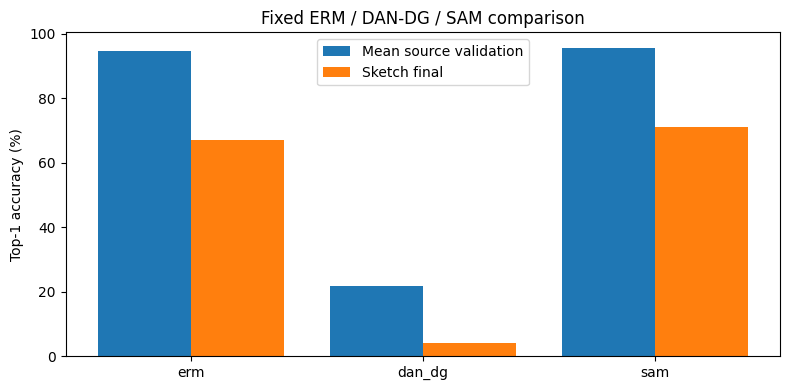

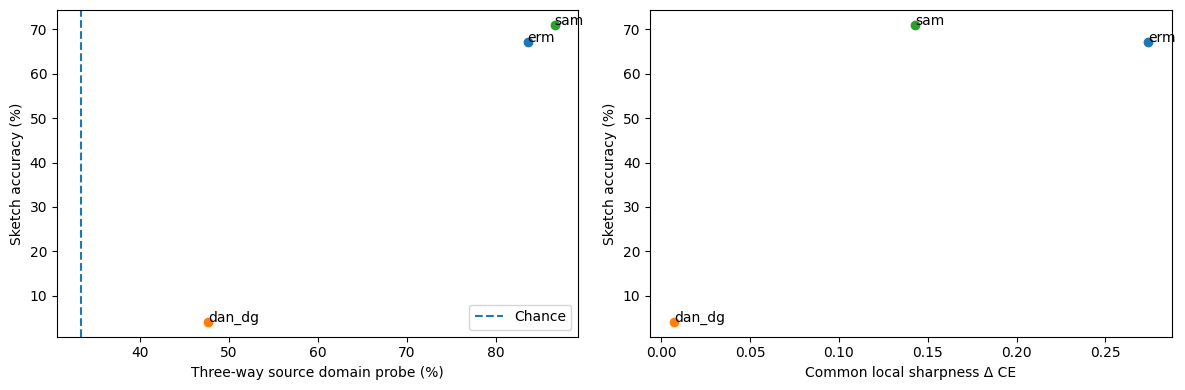

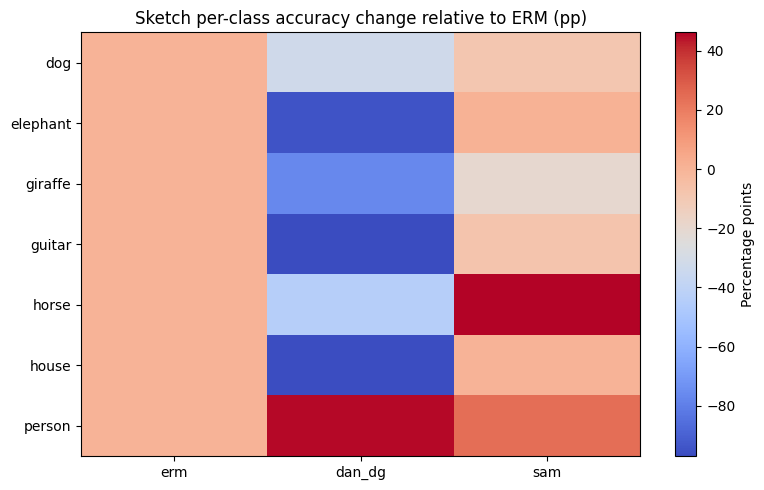

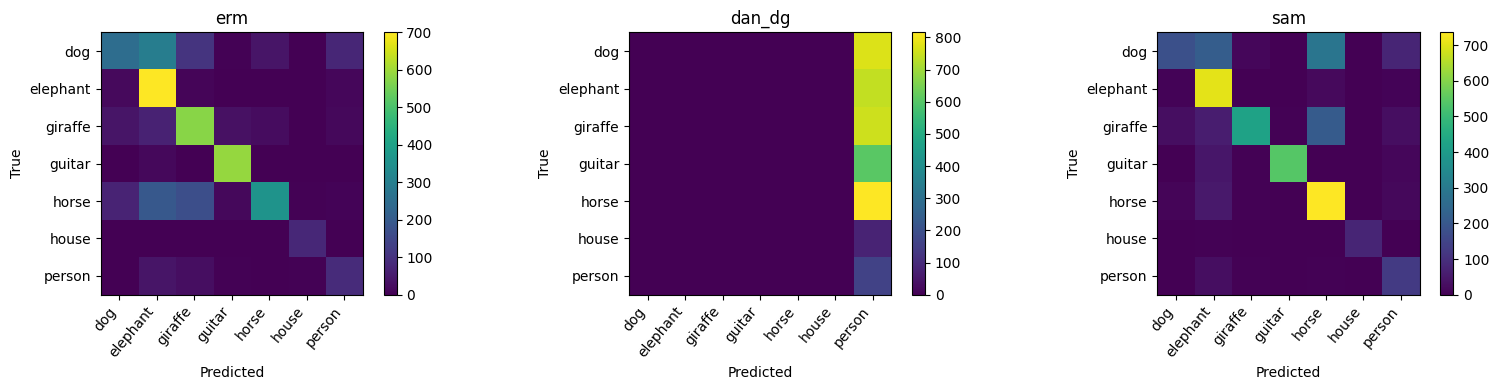

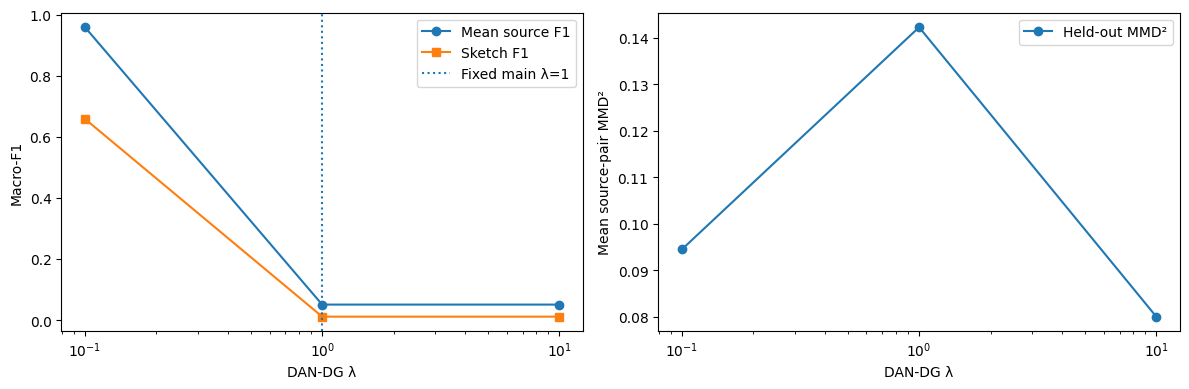

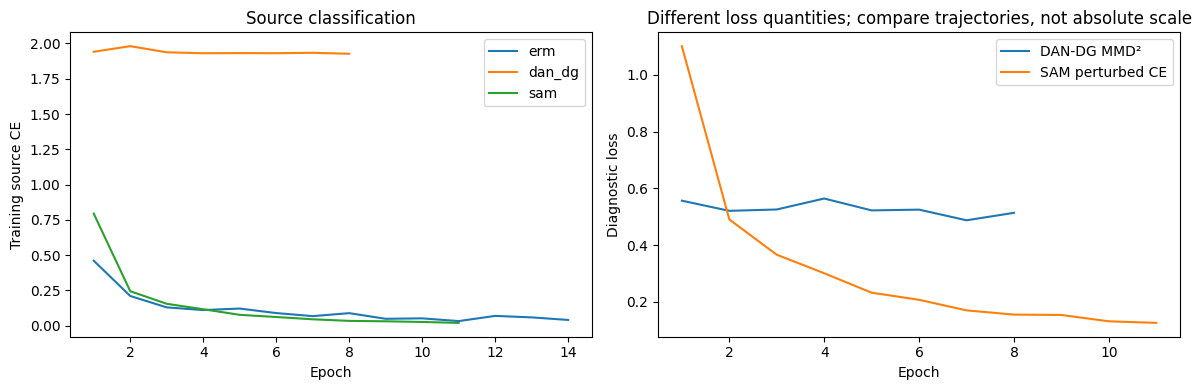

,method,sketch_accuracy,sketch_macro_f1
0,Shared ERM (Task 2/3),0.6714,0.6781
1,Target-aware DAN (Task 2),0.5561,0.5240
2,Target-free DAN-DG (Task 3),0.0407,0.0112


Saved Task 3D figures: /content/drive/MyDrive/pa1-beyond-iid/task3/results/final_eval/figures


In [9]:
#! Save final figures without changing selected checkpoints or analysis settings
names = list(MAIN_NAMES)
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(positions-.2, MAIN_TABLE['mean_accuracy']*100, width=.4, label='Mean source validation')
ax.bar(positions+.2, MAIN_TABLE['sketch_accuracy']*100, width=.4, label='Sketch final')
ax.set_xticks(positions, names)
ax.set(ylabel='Top-1 accuracy (%)', title='Fixed ERM / DAN-DG / SAM comparison')
ax.legend(); fig.tight_layout()

fig.savefig(FIG_DIR / 'main_source_vs_sketch_accuracy.png', dpi=220); plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for _, row in MAIN_TABLE.iterrows():
    axes[0].scatter(row.source_domain_separability*100, row.sketch_accuracy*100)
    axes[0].annotate(row.method, (row.source_domain_separability*100, row.sketch_accuracy*100))
    axes[1].scatter(row.common_sharpness_delta_ce, row.sketch_accuracy*100)
    axes[1].annotate(row.method, (row.common_sharpness_delta_ce, row.sketch_accuracy*100))

axes[0].axvline(100/3, linestyle='--', label='Chance')
axes[0].set(xlabel='Three-way source domain probe (%)', ylabel='Sketch accuracy (%)')
axes[0].legend()
axes[1].set(xlabel='Common local sharpness Δ CE', ylabel='Sketch accuracy (%)')

fig.tight_layout(); fig.savefig(FIG_DIR / 'source_diagnostics_vs_sketch.png', dpi=220)
plt.show(); plt.close(fig)

class_deltas = CLASS_TABLE[CLASS_TABLE.method.isin(MAIN_NAMES)].pivot(
    index='class_name', columns='method', values='delta_vs_erm_pp').reindex(
        index=LABEL_NAMES, columns=names)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(class_deltas.to_numpy(), aspect='auto', cmap='coolwarm')

ax.set_xticks(range(len(names)), names)
ax.set_yticks(range(7), LABEL_NAMES)
ax.set(title='Sketch per-class accuracy change relative to ERM (pp)')

fig.colorbar(im, ax=ax, label='Percentage points')
fig.tight_layout(); fig.savefig(FIG_DIR / 'sketch_class_delta_heatmap.png', dpi=220)

plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name in zip(axes, MAIN_NAMES):
    matrix = confusion_matrix(TARGET_TRUE, PREDICTIONS[name], labels=np.arange(7))
    picture = ax.imshow(matrix)

    ax.set_xticks(range(7), LABEL_NAMES, rotation=50, ha='right')
    ax.set_yticks(range(7), LABEL_NAMES)
    ax.set(xlabel='Predicted', ylabel='True', title=name)

    fig.colorbar(picture, ax=ax, fraction=.046)

fig.tight_layout(); fig.savefig(FIG_DIR / 'sketch_confusion_main.png', dpi=220)

plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(CONTROL_TABLE.lambda_dg, CONTROL_TABLE.source_mean_macro_f1,
             marker='o', label='Mean source F1')
axes[0].plot(CONTROL_TABLE.lambda_dg, CONTROL_TABLE.sketch_macro_f1,
             marker='s', label='Sketch F1')
axes[0].axvline(1., linestyle=':', label='Fixed main λ=1')
axes[0].set(xscale='log', xlabel='DAN-DG λ', ylabel='Macro-F1')

axes[0].legend()
axes[1].plot(CONTROL_TABLE.lambda_dg, CONTROL_TABLE.heldout_source_pair_mmd2,
             marker='o', label='Held-out MMD²')
axes[1].set(xscale='log', xlabel='DAN-DG λ', ylabel='Mean source-pair MMD²')
axes[1].legend()

fig.tight_layout(); fig.savefig(FIG_DIR / 'controlled_lambda_final.png', dpi=220)

plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in MAIN_NAMES:
    history_file = TASK2 / 'results/source_only/history.csv' if name == 'erm' else TASK3 / f'results/{name}/history.csv'

    if not history_file.is_file():
        raise FileNotFoundError('Missing training history: ' + str(history_file))

    history = pd.read_csv(history_file)
    cls_col = 'train_loss' if name == 'erm' else 'train_cls_loss'

    axes[0].plot(history.epoch, history[cls_col], label=name)

    if name == 'dan_dg':
        axes[1].plot(history.epoch, history['train_alignment_loss'], label='DAN-DG MMD²')

    if name == 'sam':
        axes[1].plot(history.epoch, history['train_perturbed_cls_loss'], label='SAM perturbed CE')

axes[0].set(xlabel='Epoch', ylabel='Training source CE', title='Source classification')
axes[1].set(xlabel='Epoch', ylabel='Diagnostic loss',
             title='Different loss quantities; compare trajectories, not absolute scale')
axes[0].legend(); axes[1].legend()

fig.tight_layout(); fig.savefig(FIG_DIR / 'main_training_curves.png', dpi=220)

plt.show(); plt.close(fig)

#! Optional Task 2 DAN vs DAN-DG: inspect only after Task 3 is frozen, for final analysis.
TASK2_FINAL = TASK2 / 'results/final_eval/target_metrics_all_methods.csv'

if TASK2_FINAL.is_file():
    prior = pd.read_csv(TASK2_FINAL).set_index('method')

    if {'source_only', 'dan'}.issubset(prior.index):
        compare = pd.DataFrame([
            {'method': 'Shared ERM (Task 2/3)',
             'sketch_accuracy': float(TARGET_TABLE.set_index('method').loc['erm', 'accuracy']),
             'sketch_macro_f1': float(TARGET_TABLE.set_index('method').loc['erm', 'macro_f1'])},
            {'method': 'Target-aware DAN (Task 2)',
             'sketch_accuracy': float(prior.loc['dan', 'accuracy']),
             'sketch_macro_f1': float(prior.loc['dan', 'macro_f1'])},
            {'method': 'Target-free DAN-DG (Task 3)',
             'sketch_accuracy': float(TARGET_TABLE.set_index('method').loc['dan_dg', 'accuracy']),
             'sketch_macro_f1': float(TARGET_TABLE.set_index('method').loc['dan_dg', 'macro_f1'])}
        ])
        compare.to_csv(RESULT_DIR / 'task2_dan_vs_task3_dan_dg.csv', index=False)
        display(compare.round(4))

        if not np.isclose(float(prior.loc['source_only', 'accuracy']), ERM_ACC, atol=1e-8):
            print('WARNING: Task 2 ERM score differs; investigate before interpreting cross-task contrast.')
    else:
        print('Task 2 final metrics lack source_only / dan; cross-task comparison deferred.')
else:
    print('Task 2G final results not yet present. Cross-task DAN comparison can be added later without retraining.')

print('Saved Task 3D figures:', FIG_DIR)

In [10]:
#! Final immutable upstream audit and required evidence inventory

REQUIRED_FILES = [LOCK_PATH, SAMPLE_PATH,
    RESULT_DIR / 'source_validation_all_models.csv',
    RESULT_DIR / 'source_domain_separability.csv',
    RESULT_DIR / 'common_local_sharpness.csv',
    RESULT_DIR / 'sketch_metrics_all_models.csv',
    RESULT_DIR / 'task3_main_comparison.csv',
    RESULT_DIR / 'controlled_dan_dg_final.csv',
    RESULT_DIR / 'sketch_per_class_transfer.csv',
    RESULT_DIR / 'paired_sketch_predictions.csv',
    RESULT_DIR / 'selected_sketch_failures.csv']

REQUIRED_FILES += [RESULT_DIR / f'confusion_{name}.csv' for name in MAIN_NAMES]

REQUIRED_FILES += [FIG_DIR / n for n in (
    'main_source_vs_sketch_accuracy.png', 'source_diagnostics_vs_sketch.png',
    'sketch_class_delta_heatmap.png', 'sketch_confusion_main.png',
    'controlled_lambda_final.png', 'main_training_curves.png')]

for name in ALL_NAMES:
    REQUIRED_FILES += [CACHE_DIR / f'{name}_{part}{suffix}'
                       for part in ('source', 'sketch')
                       for suffix in ('.npz', '_meta.json')]

missing = [str(path) for path in REQUIRED_FILES if not path.is_file() or path.stat().st_size == 0]

if missing:
    raise FileNotFoundError('Missing final evidence:\n' + '\n'.join(missing))

if json.loads(LOCK_PATH.read_text()) != FROZEN_PLAN:
    raise RuntimeError('Final evaluation plan changed after Sketch release')

if any([sha256(BASE_PATH) != FROZEN_PLAN['base_config_sha256'],
        sha256(SPLIT_PATH) != FROZEN_PLAN['source_split_sha256'],
        sha256(INITIAL_PATH) != FROZEN_PLAN['initial_checkpoint_sha256'],
        sha256(STUDY_CONFIG) != FROZEN_PLAN['study_config_sha256'],
        sha256(STUDY_TABLE) != FROZEN_PLAN['study_table_sha256'],
        sha256(SHARED / 'pacs.py') != FROZEN_PLAN['pacs_module_sha256'],
        sha256(SHARED / 'pacs_training.py') != FROZEN_PLAN['training_module_sha256'],
        sha256(SOURCE_VAL_PATH) != FROZEN_PLAN['source_validation_manifest_sha256']]):
    raise RuntimeError('An original source protocol, module, initial weights or controlled study changed')

for name in ALL_NAMES:
    entry = FROZEN[name]

    for path_key, sha_key in [('config','config_sha256'), ('best','best_sha256'), ('last','last_sha256')]:
        if sha256(ROOT / entry[path_key]) != entry[sha_key]:
            raise RuntimeError(f'{name}: training file mutated during final analysis: {path_key}')

    for part in ('source','sketch'):
        path = CACHE_DIR / f'{name}_{part}.npz'
        meta = json.loads((CACHE_DIR / f'{name}_{part}_meta.json').read_text())

        if meta['sha256'] != sha256(path):
            raise RuntimeError(f'{name} {part} cache file changed unexpectedly')

if (len(MAIN_TABLE) != 3 or len(CONTROL_TABLE) != 3 or len(CLASS_TABLE) != 7*len(ALL_NAMES)
        or len(prediction_archive) != len(TARGET_IDS)
        or not np.isclose(MAIN_TABLE.loc[MAIN_TABLE.method == 'erm','sketch_accuracy'].iloc[0], ERM_ACC)
        or not np.isclose(CONTROL_TABLE.loc[CONTROL_TABLE.lambda_dg == 1.0,'sketch_accuracy'].iloc[0],
                          MAIN_TABLE.loc[MAIN_TABLE.method == 'dan_dg','sketch_accuracy'].iloc[0])):
    raise RuntimeError('Final tables have inconsistent rows, baseline or fixed main λ')

VERIFICATION = {'task': '3D', 'seed': SEED, 'complete': True,
    'training_or_checkpoint_selection_in_this_notebook': False,
    'target_labels_first_used': 'Cell 7 after all experiment choices were frozen',
    'source_probed_domains': list(SOURCE_DOMAINS),
    'three_way_chance': 1/3, 'sharpness_rho': RHO,
    'main_models': list(MAIN_NAMES), 'controlled_lambdas': [0.1,1.,10.],
    'source_validation_n': len(SOURCE_IDS), 'sketch_evaluation_n': len(TARGET_IDS),
    'verified_evidence_files': len(REQUIRED_FILES),
    'note': 'Report language, interpretation and analysis must be written by the student.'}

(RESULT_DIR / 'verification.json').write_text(json.dumps(VERIFICATION, indent=2))

print('TASK 3D COMPLETE — FINAL EVALUATION')

print('Verified files:', len(REQUIRED_FILES), '| frozen checkpoints:', len(ALL_NAMES))
print('Sketch images:', len(TARGET_IDS), '| source/target-trained models updated: NO')
print('Results:', RESULT_DIR)

TASK 3D COMPLETE — FINAL EVALUATION
Verified files: 40 | frozen checkpoints: 5
Sketch images: 3929 | source/target-trained models updated: NO
Results: /content/drive/MyDrive/pa1-beyond-iid/task3/results/final_eval
